# UrbanShift Customer Churn / At-Risk Modelling — Tuned XGBoost on AWS SageMaker

This notebook trains, tunes, evaluates, and interprets an XGBoost classifier using the finalized feature-engineered model table.

It is designed for AWS SageMaker and uses S3 as the primary input/output layer.

**Target column:** `at_risk`  
**Columns dropped from features:** `customer_id`, `snapshot_date`  
**Categorical handling:** one-hot encoding with `pandas.get_dummies()`  
**Validation strategy:** 85% development / 15% final holdout test split, with 5-fold stratified cross-validation on the development set  
**Tuning method:** `RandomizedSearchCV`  
**Primary selection metric:** ROC-AUC  
**Secondary metrics:** PR-AUC, F1, precision, recall  
**Interpretability included:** XGBoost feature importance, CV result review, confusion matrix, ROC curve, precision-recall curve, and saved analysis artifacts.

The final test set is not used during hyperparameter tuning or threshold selection.


## 1. Install and import dependencies

In [1]:
%pip install -q awswrangler xgboost scikit-learn joblib matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import warnings
import tempfile
from io import BytesIO

import awswrangler as wr
import boto3
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)


## 2. Configure S3 paths



In [3]:
S3_INPUT_PATH = "s3://urbanshift-data-1781521886-rjjrqj/feature_engineering/customer_churn_model_table.csv"
S3_OUTPUT_PREFIX = "s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/"

print("Input:", S3_INPUT_PATH)
print("Output prefix:", S3_OUTPUT_PREFIX)


Input: s3://urbanshift-data-1781521886-rjjrqj/feature_engineering/customer_churn_model_table.csv
Output prefix: s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/


## 3. Load model table from S3


In [4]:
df = wr.s3.read_csv(S3_INPUT_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))


Shape: (714, 22)


,customer_id,snapshot_date,customer_size,city,industry,industry_revenue_share,industry_relative_revenue_strength,payment_terms_days,customer_tenure_days,avg_revenue_per_delivery_lookback_60d,relative_volume_strength,volume_growth_lookback,relative_volume_growth_lookback,failed_delivery_rate_lookback_60d,return_rate_lookback_60d,avg_delivery_time_lookback_60d,incident_rate_lookback_60d,complaint_rate_lookback_60d,late_delivery_rate_lookback_60d,damaged_parcel_rate_lookback_60d,lost_parcel_rate_lookback_60d,at_risk
0,CUST1000,2024-11-30,Mid-size Retailer,London,Beauty,0.123535,0.0,60,901,5.948517,2.484211,-0.081301,-0.146712,0.042373,0.016949,72.724576,0.169492,0.038136,0.016949,0.046610,0.012712,0
1,CUST1001,2024-11-30,Mid-size Retailer,London,Books,0.088978,0.0,30,199,6.066206,3.884211,-0.016129,-0.081540,0.037940,0.027100,70.051491,0.176152,0.029810,0.032520,0.040650,0.016260,0
2,CUST1002,2024-11-30,Small Retailer,Bristol,Fashion,0.363793,0.0,30,759,4.657647,0.536842,-0.038462,-0.103873,0.078431,0.058824,65.039216,0.294118,0.039216,0.098039,0.058824,0.058824,0
3,CUST1003,2024-11-30,Small Retailer,Leeds,Beauty,0.123535,0.0,60,155,4.654000,0.368421,-0.157895,-0.223306,0.028571,0.057143,66.514286,0.200000,0.057143,0.057143,0.028571,0.000000,0
4,CUST1004,2024-11-30,Small Retailer,Manchester,Electronics,0.128233,0.0,30,886,4.626983,1.221053,-0.066667,-0.132078,0.051724,0.034483,66.025862,0.284483,0.034483,0.068966,0.068966,0.025862,0


,dtype
customer_id,object
snapshot_date,object
customer_size,object
city,object
industry,object
industry_revenue_share,float64
industry_relative_revenue_strength,float64
payment_terms_days,int64
customer_tenure_days,int64
avg_revenue_per_delivery_lookback_60d,float64


## 4. Basic target and feature checks


In [5]:
TARGET_COL = "at_risk"
DROP_COLS = ["customer_id", "snapshot_date"]

required_cols = [TARGET_COL] + DROP_COLS
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Target distribution:")
display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))
print("Target rate:", round(df[TARGET_COL].mean(), 4))

print("Duplicate customer/snapshot rows:", df.duplicated(subset=DROP_COLS).sum())
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))


Target distribution:


,count
at_risk,
0,652
1,62


Target rate: 0.0868
Duplicate customer/snapshot rows: 0
Missing values by column:


,missing_count
customer_id,0
snapshot_date,0
customer_size,0
city,0
industry,0
industry_revenue_share,0
industry_relative_revenue_strength,0
payment_terms_days,0
customer_tenure_days,0
avg_revenue_per_delivery_lookback_60d,0


## 5. Prepare features and target

This drops identifiers/date fields and one-hot encodes remaining string columns.


In [6]:
X_raw = df.drop(columns=DROP_COLS + [TARGET_COL])
y = df[TARGET_COL].astype(int)

categorical_cols = X_raw.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = X_raw.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True, dtype=int)

print("Encoded feature matrix shape:", X.shape)
display(X.head())


Categorical columns: ['customer_size', 'city', 'industry']
Numeric columns: ['industry_revenue_share', 'industry_relative_revenue_strength', 'payment_terms_days', 'customer_tenure_days', 'avg_revenue_per_delivery_lookback_60d', 'relative_volume_strength', 'volume_growth_lookback', 'relative_volume_growth_lookback', 'failed_delivery_rate_lookback_60d', 'return_rate_lookback_60d', 'avg_delivery_time_lookback_60d', 'incident_rate_lookback_60d', 'complaint_rate_lookback_60d', 'late_delivery_rate_lookback_60d', 'damaged_parcel_rate_lookback_60d', 'lost_parcel_rate_lookback_60d']
Encoded feature matrix shape: (714, 29)


,industry_revenue_share,industry_relative_revenue_strength,payment_terms_days,customer_tenure_days,avg_revenue_per_delivery_lookback_60d,relative_volume_strength,volume_growth_lookback,relative_volume_growth_lookback,failed_delivery_rate_lookback_60d,return_rate_lookback_60d,avg_delivery_time_lookback_60d,incident_rate_lookback_60d,complaint_rate_lookback_60d,late_delivery_rate_lookback_60d,damaged_parcel_rate_lookback_60d,lost_parcel_rate_lookback_60d,customer_size_Mid-size Retailer,customer_size_Small Retailer,city_Bristol,city_Glasgow,city_Leeds,city_London,city_Manchester,industry_Books,industry_Electronics,industry_Fashion,industry_Food & Drink,industry_Home,industry_Other
0,0.123535,0.0,60,901,5.948517,2.484211,-0.081301,-0.146712,0.042373,0.016949,72.724576,0.169492,0.038136,0.016949,0.046610,0.012712,1,0,0,0,0,1,0,0,0,0,0,0,0
1,0.088978,0.0,30,199,6.066206,3.884211,-0.016129,-0.081540,0.037940,0.027100,70.051491,0.176152,0.029810,0.032520,0.040650,0.016260,1,0,0,0,0,1,0,1,0,0,0,0,0
2,0.363793,0.0,30,759,4.657647,0.536842,-0.038462,-0.103873,0.078431,0.058824,65.039216,0.294118,0.039216,0.098039,0.058824,0.058824,0,1,1,0,0,0,0,0,0,1,0,0,0
3,0.123535,0.0,60,155,4.654000,0.368421,-0.157895,-0.223306,0.028571,0.057143,66.514286,0.200000,0.057143,0.057143,0.028571,0.000000,0,1,0,0,1,0,0,0,0,0,0,0,0
4,0.128233,0.0,30,886,4.626983,1.221053,-0.066667,-0.132078,0.051724,0.034483,66.025862,0.284483,0.034483,0.068966,0.068966,0.025862,0,1,0,0,0,0,1,0,1,0,0,0,0


## 6. Development / final test split

The data is split into:

- **85% development set**: used for 5-fold cross-validation, hyperparameter tuning, and threshold selection using out-of-fold predictions.
- **15% final holdout test set**: used once at the end for final model evaluation.

The split is stratified so the target rate is preserved.


In [7]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame({
    "split": ["development", "test"],
    "rows": [len(X_dev), len(X_test)],
    "target_rate": [y_dev.mean(), y_test.mean()],
})

print("Development shape:", X_dev.shape)
print("Test shape:", X_test.shape)
display(split_summary)


Development shape: (606, 29)
Test shape: (108, 29)


,split,rows,target_rate
0,development,606,0.087459
1,test,108,0.083333


## 7. Tune XGBoost with stratified 5-fold cross-validation

`RandomizedSearchCV` searches across a controlled hyperparameter space using only the development set.

The final holdout test set is not touched during this stage.


In [8]:
negative_count = (y_dev == 0).sum()
positive_count = (y_dev == 1).sum()
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

base_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

param_distributions = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
    "subsample": [0.70, 0.80, 0.90, 1.00],
    "colsample_bytree": [0.70, 0.80, 0.90, 1.00],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.05, 0.10, 0.20],
    "reg_alpha": [0, 0.01, 0.10, 1.00],
    "reg_lambda": [0.50, 1.00, 2.00, 5.00],
}

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
}

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=50,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

search.fit(X_dev, y_dev)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best hyperparameters:")
print(json.dumps(search.best_params_, indent=2))

cv_results_df = pd.DataFrame(search.cv_results_).sort_values("rank_test_roc_auc")
summary_cols = [
    "rank_test_roc_auc",
    "mean_test_roc_auc",
    "std_test_roc_auc",
    "mean_test_pr_auc",
    "mean_test_f1",
    "mean_test_recall",
    "mean_test_precision",
    "mean_train_roc_auc",
    "params",
]
display(cv_results_df[summary_cols].head(10))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV ROC-AUC: 0.9464
Best hyperparameters:
{
  "subsample": 0.9,
  "reg_lambda": 1.0,
  "reg_alpha": 0.1,
  "n_estimators": 100,
  "min_child_weight": 3,
  "max_depth": 2,
  "learning_rate": 0.1,
  "gamma": 0.2,
  "colsample_bytree": 0.7
}


,rank_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,mean_test_f1,mean_test_recall,mean_test_precision,mean_train_roc_auc,params
0,1,0.946431,0.017468,0.746215,0.676217,0.830909,0.579167,0.998677,"{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.7}"
6,2,0.942289,0.022507,0.734981,0.701609,0.774545,0.660000,1.000000,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}"
28,3,0.942243,0.014986,0.723159,0.671117,0.792727,0.603458,0.999153,"{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.7}"
22,4,0.941957,0.011413,0.742618,0.679448,0.776364,0.617628,0.999842,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}"
29,5,0.940934,0.026852,0.724135,0.719222,0.720000,0.737692,1.000000,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.8}"
49,6,0.939680,0.023612,0.737225,0.700645,0.718182,0.703056,1.000000,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.7}"
14,7,0.939649,0.024027,0.715112,0.680657,0.756364,0.638788,0.999979,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}"
32,8,0.939451,0.023801,0.719652,0.678018,0.718182,0.656993,1.000000,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}"
21,9,0.939054,0.020125,0.728907,0.685173,0.774545,0.628959,0.999799,"{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}"
7,10,0.938487,0.027670,0.709445,0.675308,0.698182,0.672549,1.000000,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}"


## 8. Select threshold using out-of-fold development predictions

Threshold selection is done using out-of-fold predictions from the development set. This avoids choosing a threshold based on the final test set.


In [9]:
best_xgb_for_oof = search.best_estimator_

oof_proba = cross_val_predict(
    best_xgb_for_oof,
    X_dev,
    y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    pred = (oof_proba >= threshold).astype(int)
    threshold_rows.append({
        "split": "development_oof",
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_dev, pred, zero_division=0),
        "recall": recall_score(y_dev, pred, zero_division=0),
        "f1": f1_score(y_dev, pred, zero_division=0),
        "predicted_positive_rate": float(pred.mean()),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = float(threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"])

print("Top thresholds by out-of-fold development F1:")
display(threshold_df.sort_values("f1", ascending=False).head(10))
print("Selected threshold:", best_threshold)


Top thresholds by out-of-fold development F1:


,split,threshold,precision,recall,f1,predicted_positive_rate
12,development_oof,0.70,0.711538,0.698113,0.704762,0.085809
13,development_oof,0.75,0.772727,0.641509,0.701031,0.072607
10,development_oof,0.60,0.630769,0.773585,0.694915,0.107261
9,development_oof,0.55,0.591549,0.792453,0.677419,0.117162
8,development_oof,0.50,0.564103,0.830189,0.671756,0.128713
11,development_oof,0.65,0.637931,0.698113,0.666667,0.095710
7,development_oof,0.45,0.529412,0.849057,0.652174,0.140264
14,development_oof,0.80,0.805556,0.547170,0.651685,0.059406
6,development_oof,0.40,0.511364,0.849057,0.638298,0.145215
5,development_oof,0.35,0.478723,0.849057,0.612245,0.155116


Selected threshold: 0.7


## 9. Train final tuned XGBoost model on the full development set

The selected hyperparameters are refit on the full development set before the one-time final test evaluation.


In [10]:
xgb_model = search.best_estimator_
xgb_model.fit(X_dev, y_dev)

print("Final tuned model trained on full development set.")
print("scale_pos_weight:", round(scale_pos_weight, 3))
print("Best parameters:")
print(json.dumps(search.best_params_, indent=2))


Final tuned model trained on full development set.
scale_pos_weight: 10.434
Best parameters:
{
  "subsample": 0.9,
  "reg_lambda": 1.0,
  "reg_alpha": 0.1,
  "n_estimators": 100,
  "min_child_weight": 3,
  "max_depth": 2,
  "learning_rate": 0.1,
  "gamma": 0.2,
  "colsample_bytree": 0.7
}


## 10. Final test evaluation

The final holdout test set is evaluated once after tuning and threshold selection are complete.


In [11]:
def evaluate_binary_classifier(model, X_eval, y_eval, split_name: str, threshold: float = 0.5):
    """Return probabilities, predictions, metrics, report, and confusion matrix for a split."""
    y_proba_eval = model.predict_proba(X_eval)[:, 1]
    y_pred_eval = (y_proba_eval >= threshold).astype(int)

    metrics_eval = {
        "split": split_name,
        "roc_auc": roc_auc_score(y_eval, y_proba_eval),
        "pr_auc": average_precision_score(y_eval, y_proba_eval),
        "accuracy": accuracy_score(y_eval, y_pred_eval),
        "precision": precision_score(y_eval, y_pred_eval, zero_division=0),
        "recall": recall_score(y_eval, y_pred_eval, zero_division=0),
        "f1": f1_score(y_eval, y_pred_eval, zero_division=0),
        "threshold": threshold,
        "rows": int(len(X_eval)),
        "target_rate": float(y_eval.mean()),
    }

    report_eval = classification_report(y_eval, y_pred_eval, zero_division=0)
    confusion_eval = pd.DataFrame(
        confusion_matrix(y_eval, y_pred_eval),
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"],
    )

    return y_proba_eval, y_pred_eval, metrics_eval, report_eval, confusion_eval

y_proba_05, y_pred_05, test_metrics_05, test_report_05, test_confusion_05 = evaluate_binary_classifier(
    xgb_model, X_test, y_test, "test_threshold_0_5", threshold=0.5
)

y_proba, y_pred, test_metrics_selected, test_report_selected, test_confusion_selected = evaluate_binary_classifier(
    xgb_model, X_test, y_test, "test_selected_threshold", threshold=best_threshold
)

metrics_df = pd.DataFrame([test_metrics_05, test_metrics_selected])
display(metrics_df)

print("Classification report at selected threshold:")
print(test_report_selected)

print("Confusion matrix at selected threshold:")
display(test_confusion_selected)

metrics = {
    "model": "xgboost_tuned_randomized_search_cv",
    "target_col": TARGET_COL,
    "selection_metric": "roc_auc",
    "cv_folds": 5,
    "random_search_iterations": 50,
    "selected_threshold": best_threshold,
    "development_rows": int(len(X_dev)),
    "test_rows": int(len(X_test)),
    "feature_count": int(X.shape[1]),
    "scale_pos_weight": float(scale_pos_weight),
    "best_cv_roc_auc": float(search.best_score_),
    "best_params": search.best_params_,
    "test_threshold_0_5": test_metrics_05,
    "test_selected_threshold": test_metrics_selected,
}

print(json.dumps(metrics, indent=2))


,split,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold,rows,target_rate
0,test_threshold_0_5,0.955107,0.742698,0.907407,0.470588,0.888889,0.615385,0.5,108,0.083333
1,test_selected_threshold,0.955107,0.742698,0.925926,0.533333,0.888889,0.666667,0.7,108,0.083333


Classification report at selected threshold:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96        99
           1       0.53      0.89      0.67         9

    accuracy                           0.93       108
   macro avg       0.76      0.91      0.81       108
weighted avg       0.95      0.93      0.93       108

Confusion matrix at selected threshold:


,Predicted 0,Predicted 1
Actual 0,92,7
Actual 1,1,8


{
  "model": "xgboost_tuned_randomized_search_cv",
  "target_col": "at_risk",
  "selection_metric": "roc_auc",
  "cv_folds": 5,
  "random_search_iterations": 50,
  "selected_threshold": 0.7,
  "development_rows": 606,
  "test_rows": 108,
  "feature_count": 29,
  "scale_pos_weight": 10.433962264150944,
  "best_cv_roc_auc": 0.9464313900677537,
  "best_params": {
    "subsample": 0.9,
    "reg_lambda": 1.0,
    "reg_alpha": 0.1,
    "n_estimators": 100,
    "min_child_weight": 3,
    "max_depth": 2,
    "learning_rate": 0.1,
    "gamma": 0.2,
    "colsample_bytree": 0.7
  },
  "test_threshold_0_5": {
    "split": "test_threshold_0_5",
    "roc_auc": 0.9551066217732884,
    "pr_auc": 0.7426978114478116,
    "accuracy": 0.9074074074074074,
    "precision": 0.47058823529411764,
    "recall": 0.8888888888888888,
    "f1": 0.6153846153846154,
    "threshold": 0.5,
    "rows": 108,
    "target_rate": 0.08333333333333333
  },
  "test_selected_threshold": {
    "split": "test_selected_threshold",

## 11. Model metrics analysis

This section summarises the tuned model's cross-validation performance and final holdout test performance. The test set is still only used after model selection is complete.


In [12]:
# Compact CV summary for the selected model
cv_summary = pd.DataFrame({
    "metric": [
        "CV ROC-AUC",
        "CV PR-AUC",
        "CV F1",
        "CV Recall",
        "CV Precision",
    ],
    "mean": [
        search.cv_results_["mean_test_roc_auc"][search.best_index_],
        search.cv_results_["mean_test_pr_auc"][search.best_index_],
        search.cv_results_["mean_test_f1"][search.best_index_],
        search.cv_results_["mean_test_recall"][search.best_index_],
        search.cv_results_["mean_test_precision"][search.best_index_],
    ],
    "std": [
        search.cv_results_["std_test_roc_auc"][search.best_index_],
        search.cv_results_["std_test_pr_auc"][search.best_index_],
        search.cv_results_["std_test_f1"][search.best_index_],
        search.cv_results_["std_test_recall"][search.best_index_],
        search.cv_results_["std_test_precision"][search.best_index_],
    ],
})

print("Selected model cross-validation summary:")
display(cv_summary)

print("Final holdout test metrics:")
display(metrics_df)

generalisation_gap = float(search.best_score_ - test_metrics_selected["roc_auc"])
print(f"CV ROC-AUC minus final test ROC-AUC: {generalisation_gap:.4f}")

if abs(generalisation_gap) <= 0.05:
    print("Interpretation: CV and test ROC-AUC are broadly aligned.")
elif generalisation_gap > 0.05:
    print("Interpretation: final test ROC-AUC is noticeably below CV performance; possible mild overfitting or split sensitivity.")
else:
    print("Interpretation: final test ROC-AUC is higher than CV performance; the test split may be slightly easier than the CV folds.")


Selected model cross-validation summary:


,metric,mean,std
0,CV ROC-AUC,0.946431,0.017468
1,CV PR-AUC,0.746215,0.077823
2,CV F1,0.676217,0.038187
3,CV Recall,0.830909,0.067444
4,CV Precision,0.579167,0.075000


Final holdout test metrics:


,split,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold,rows,target_rate
0,test_threshold_0_5,0.955107,0.742698,0.907407,0.470588,0.888889,0.615385,0.5,108,0.083333
1,test_selected_threshold,0.955107,0.742698,0.925926,0.533333,0.888889,0.666667,0.7,108,0.083333


CV ROC-AUC minus final test ROC-AUC: -0.0087
Interpretation: CV and test ROC-AUC are broadly aligned.


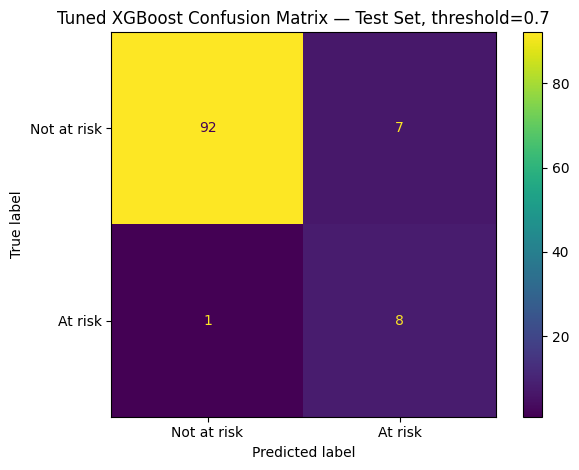

In [13]:
# Confusion matrix plot at the selected threshold
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not at risk", "At risk"],
    values_format="d",
)
plt.title(f"Tuned XGBoost Confusion Matrix — Test Set, threshold={best_threshold}")
plt.tight_layout()
plt.show()


,rank_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,mean_test_f1,mean_test_recall,mean_test_precision,mean_train_roc_auc,params
0,1,0.946431,0.017468,0.746215,0.676217,0.830909,0.579167,0.998677,"{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.7}"
6,2,0.942289,0.022507,0.734981,0.701609,0.774545,0.660000,1.000000,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}"
28,3,0.942243,0.014986,0.723159,0.671117,0.792727,0.603458,0.999153,"{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.7}"
22,4,0.941957,0.011413,0.742618,0.679448,0.776364,0.617628,0.999842,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}"
29,5,0.940934,0.026852,0.724135,0.719222,0.720000,0.737692,1.000000,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.8}"
49,6,0.939680,0.023612,0.737225,0.700645,0.718182,0.703056,1.000000,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.08, 'gamma': 0.1, 'colsample_bytree': 0.7}"
14,7,0.939649,0.024027,0.715112,0.680657,0.756364,0.638788,0.999979,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}"
32,8,0.939451,0.023801,0.719652,0.678018,0.718182,0.656993,1.000000,"{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}"
21,9,0.939054,0.020125,0.728907,0.685173,0.774545,0.628959,0.999799,"{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}"
7,10,0.938487,0.027670,0.709445,0.675308,0.698182,0.672549,1.000000,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}"


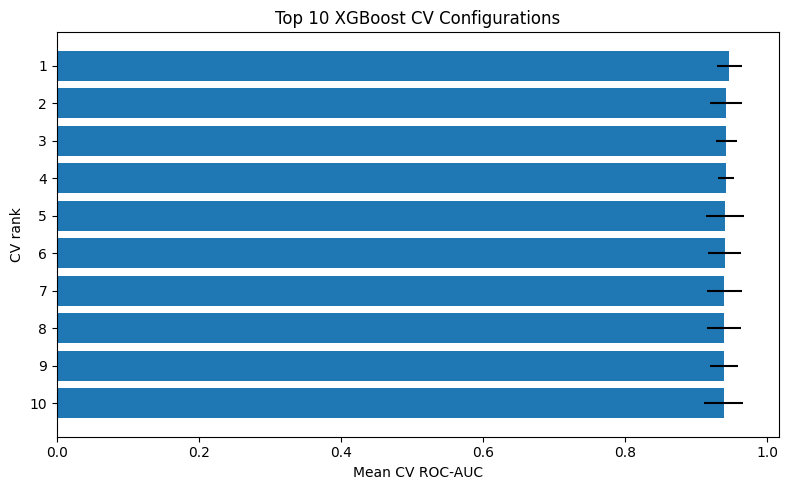

In [14]:
# Review the top CV search results to see how close the leading configurations were
cv_leaderboard = cv_results_df[[
    "rank_test_roc_auc",
    "mean_test_roc_auc",
    "std_test_roc_auc",
    "mean_test_pr_auc",
    "mean_test_f1",
    "mean_test_recall",
    "mean_test_precision",
    "mean_train_roc_auc",
    "params",
]].head(10).copy()

display(cv_leaderboard)

cv_leaderboard_plot = cv_leaderboard.sort_values("mean_test_roc_auc", ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(
    cv_leaderboard_plot["rank_test_roc_auc"].astype(str),
    cv_leaderboard_plot["mean_test_roc_auc"],
    xerr=cv_leaderboard_plot["std_test_roc_auc"],
)
plt.xlabel("Mean CV ROC-AUC")
plt.ylabel("CV rank")
plt.title("Top 10 XGBoost CV Configurations")
plt.tight_layout()
plt.show()


## 12. ROC and precision-recall curves

The plots below show final holdout test-set performance.


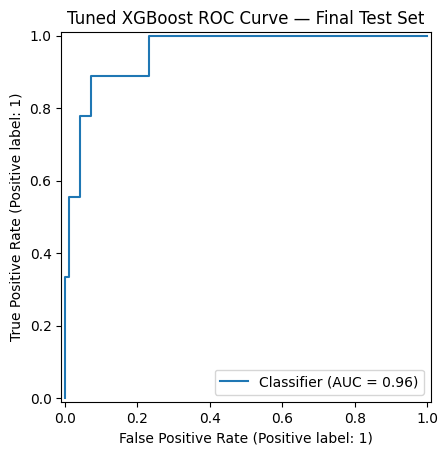

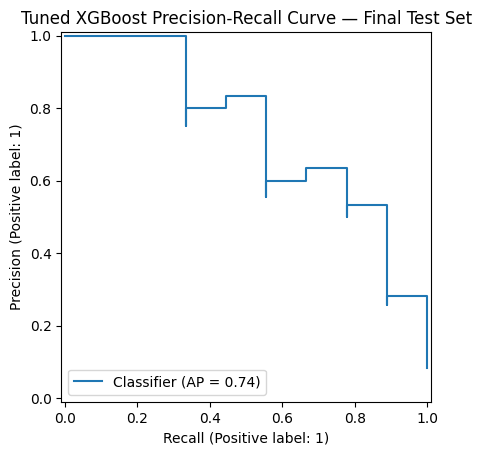

In [15]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Tuned XGBoost ROC Curve — Final Test Set")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Tuned XGBoost Precision-Recall Curve — Final Test Set")
plt.show()


## 13. Feature importance analysis

This section reports several XGBoost feature-importance views.

- **Sklearn importance**: the model's default feature importance output.
- **Gain**: average improvement in model loss from splits using the feature.
- **Weight**: how often the feature is used in splits.
- **Cover**: average number of observations affected by splits using the feature.

For the final report, treat these as model diagnostics rather than causal explanations.


Top 20 features by default XGBoost importance:


,feature,importance
7,relative_volume_growth_lookback,0.226685
6,volume_growth_lookback,0.136210
21,city_London,0.067341
5,relative_volume_strength,0.049804
20,city_Leeds,0.049736
0,industry_revenue_share,0.045163
10,avg_delivery_time_lookback_60d,0.043019
4,avg_revenue_per_delivery_lookback_60d,0.042817
3,customer_tenure_days,0.042038
8,failed_delivery_rate_lookback_60d,0.034047


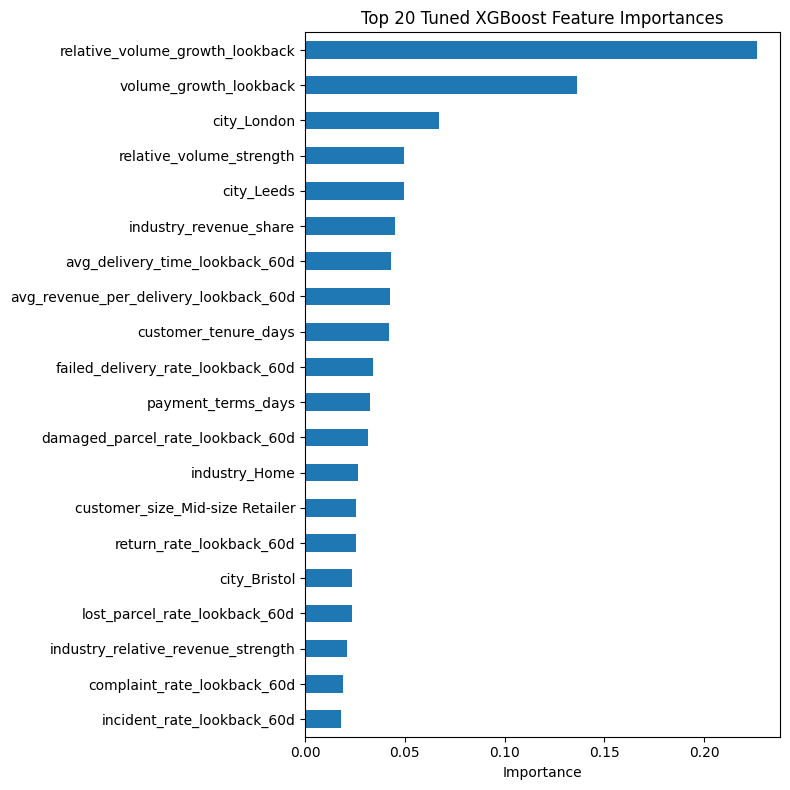

Top 20 features by gain:


,feature,gain,weight,cover
18,relative_volume_growth_lookback,75.920555,30.0,145.561188
21,volume_growth_lookback,45.619122,35.0,95.556892
4,city_London,22.553638,1.0,61.269966
19,relative_volume_strength,16.680178,29.0,85.022949
3,city_Leeds,16.657553,6.0,95.804085
14,industry_revenue_share,15.125799,11.0,71.369217
0,avg_delivery_time_lookback_60d,14.407930,34.0,87.050415
1,avg_revenue_per_delivery_lookback_60d,14.340001,24.0,63.526352
7,customer_tenure_days,14.079299,30.0,79.838646
9,failed_delivery_rate_lookback_60d,11.403033,9.0,57.416031


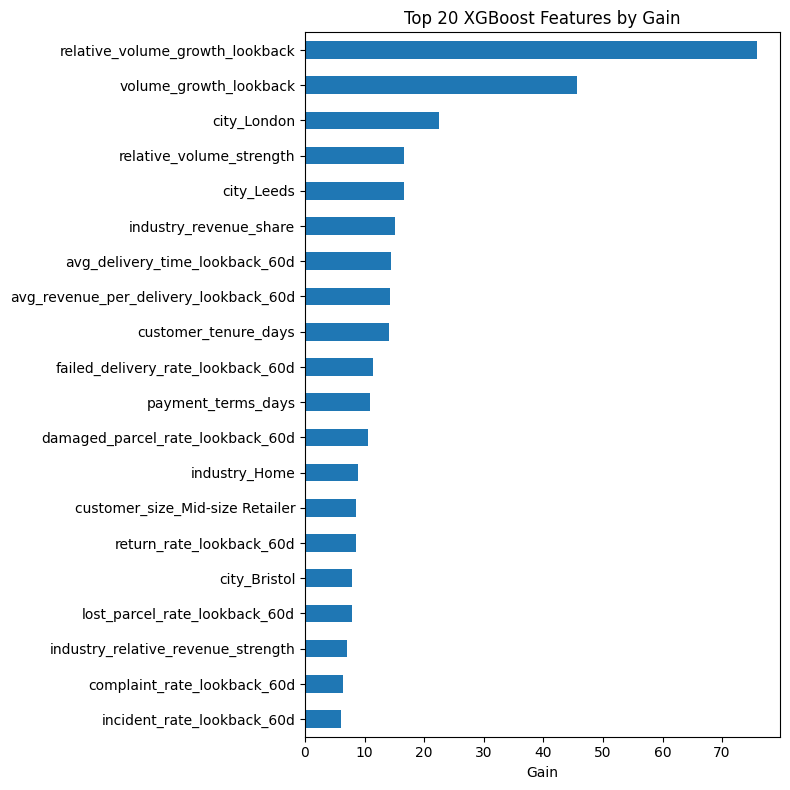

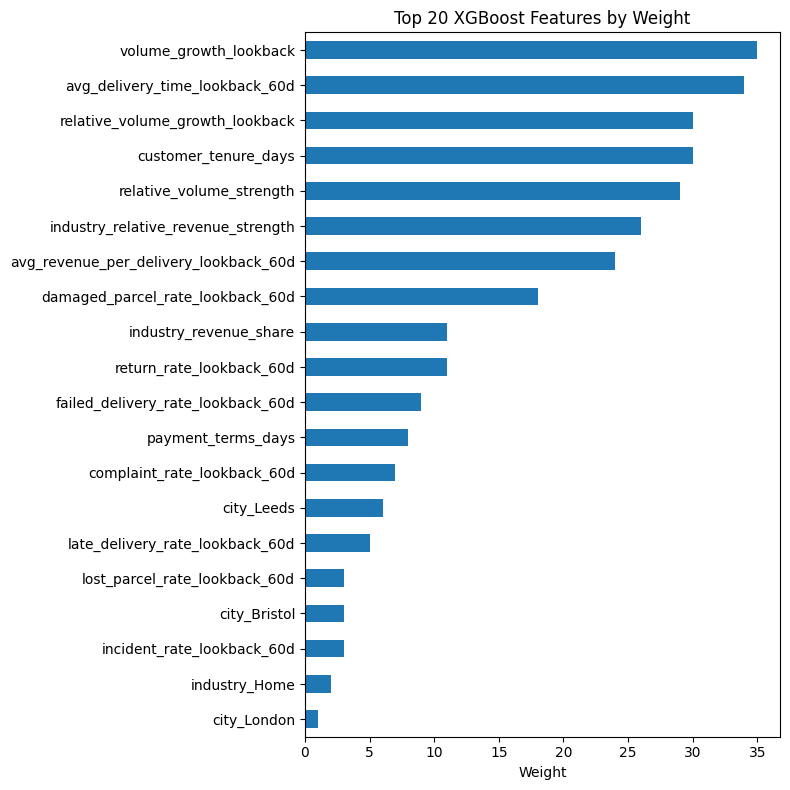

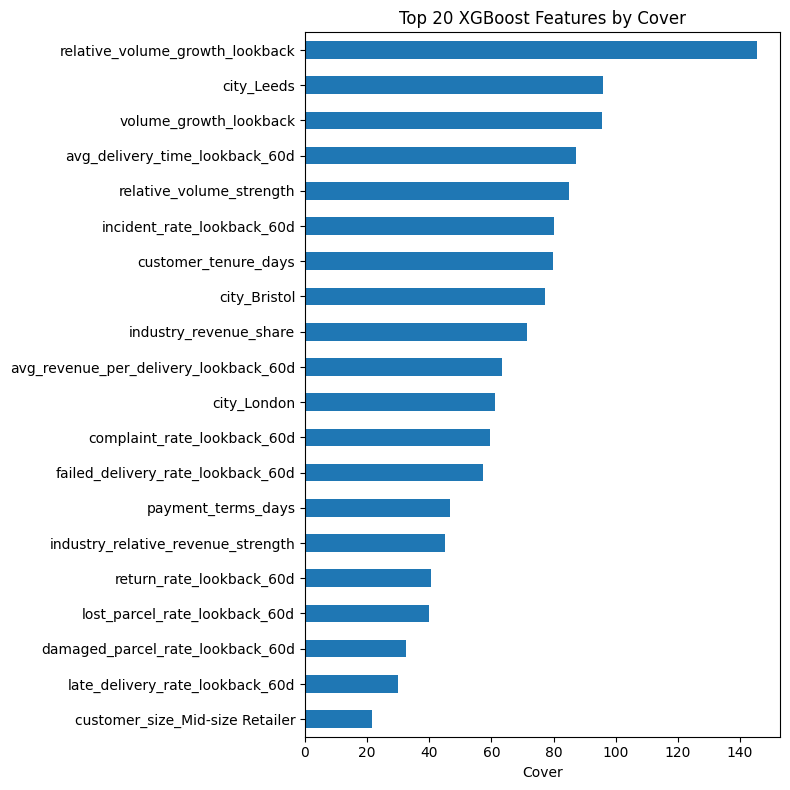

In [17]:
# Default sklearn-style XGBoost feature importance
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 20 features by default XGBoost importance:")
display(feature_importance.head(20))

feature_importance.head(20).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    figsize=(8, 8),
)
plt.title("Top 20 Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Booster-level importance scores by type
booster = xgb_model.get_booster()
importance_frames = []

for importance_type in ["gain", "weight", "cover"]:
    scores = booster.get_score(importance_type=importance_type)
    frame = pd.DataFrame({
        "feature": list(scores.keys()),
        importance_type: list(scores.values()),
    })
    importance_frames.append(frame)

booster_importance = importance_frames[0]
for frame in importance_frames[1:]:
    booster_importance = booster_importance.merge(frame, on="feature", how="outer")

booster_importance = booster_importance.fillna(0)

feature_name_map = {f"f{i}": col for i, col in enumerate(X.columns)}
booster_importance["feature"] = booster_importance["feature"].map(lambda x: feature_name_map.get(x, x))
booster_importance = booster_importance.sort_values("gain", ascending=False)

print("Top 20 features by gain:")
display(booster_importance.head(20))

for importance_type in ["gain", "weight", "cover"]:
    plot_df = booster_importance.sort_values(importance_type, ascending=False).head(20)
    plot_df.sort_values(importance_type).plot(
        kind="barh",
        x="feature",
        y=importance_type,
        legend=False,
        figsize=(8, 8),
    )
    plt.title(f"Top 20 XGBoost Features by {importance_type.title()}")
    plt.xlabel(importance_type.title())
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


## 14. Save model outputs and analysis artifacts to S3

Tabular and JSON artifacts are written directly to S3. The trained model is written to a temporary local file only because `joblib` requires a filesystem path before upload. Plot images are streamed to S3 from memory, not persisted locally.

Saved outputs include CV results, final test metrics, threshold review, feature importance, booster importance, test predictions, feature columns, selected parameters, analysis plots, and the trained model.


In [18]:
# Build prediction output with identifiers for auditability
predictions = df.loc[X_test.index, DROP_COLS + [TARGET_COL]].copy()
predictions["predicted_probability_at_risk"] = y_proba
predictions["predicted_at_risk_0_5"] = y_pred_05
predictions[f"predicted_at_risk_{str(best_threshold).replace('.', '_')}"] = y_pred

# Normalise S3 prefix so path concatenation is safe
if not S3_OUTPUT_PREFIX.endswith("/"):
    S3_OUTPUT_PREFIX = S3_OUTPUT_PREFIX + "/"

# S3 artifact paths
metrics_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_metrics.json"
metrics_csv_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_test_metrics.csv"
cv_summary_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_cv_summary.csv"
cv_results_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_cv_results.csv"
cv_leaderboard_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_cv_leaderboard.csv"
threshold_review_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_oof_threshold_review.csv"
feature_importance_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_feature_importance.csv"
booster_importance_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_booster_importance.csv"
predictions_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_test_predictions.csv"
feature_columns_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_feature_columns.json"
best_params_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_best_params.json"
model_s3_path = S3_OUTPUT_PREFIX + "xgboost_tuned_model.joblib"

roc_plot_s3_path = S3_OUTPUT_PREFIX + "plots/xgboost_tuned_roc_curve.png"
pr_plot_s3_path = S3_OUTPUT_PREFIX + "plots/xgboost_tuned_precision_recall_curve.png"
confusion_plot_s3_path = S3_OUTPUT_PREFIX + "plots/xgboost_tuned_confusion_matrix.png"
feature_importance_plot_s3_path = S3_OUTPUT_PREFIX + "plots/xgboost_tuned_feature_importance_top20.png"

# Save tabular outputs directly to S3
wr.s3.to_csv(df=metrics_df, path=metrics_csv_s3_path, index=False)
wr.s3.to_csv(df=cv_summary, path=cv_summary_s3_path, index=False)
wr.s3.to_csv(df=cv_results_df, path=cv_results_s3_path, index=False)
wr.s3.to_csv(df=cv_leaderboard, path=cv_leaderboard_s3_path, index=False)
wr.s3.to_csv(df=threshold_df, path=threshold_review_s3_path, index=False)
wr.s3.to_csv(df=feature_importance, path=feature_importance_s3_path, index=False)
wr.s3.to_csv(df=booster_importance, path=booster_importance_s3_path, index=False)
wr.s3.to_csv(df=predictions, path=predictions_s3_path, index=False)

# Save JSON outputs directly to S3 using boto3
s3 = boto3.client("s3")

def parse_s3_uri(s3_uri: str) -> tuple[str, str]:
    """Split an S3 URI into bucket and key."""
    if not s3_uri.startswith("s3://"):
        raise ValueError(f"Expected an S3 URI, got: {s3_uri}")
    bucket_key = s3_uri.replace("s3://", "", 1)
    bucket, key = bucket_key.split("/", 1)
    return bucket, key

def put_json_to_s3(payload, s3_uri: str) -> None:
    """Write JSON-serialisable payload directly to S3."""
    bucket, key = parse_s3_uri(s3_uri)
    s3.put_object(
        Bucket=bucket,
        Key=key,
        Body=json.dumps(payload, indent=2).encode("utf-8"),
        ContentType="application/json",
    )

def put_current_figure_to_s3(s3_uri: str, dpi: int = 150) -> None:
    """Write the current matplotlib figure to S3 from memory."""
    bucket, key = parse_s3_uri(s3_uri)
    buffer = BytesIO()
    plt.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    buffer.seek(0)
    s3.put_object(
        Bucket=bucket,
        Key=key,
        Body=buffer.getvalue(),
        ContentType="image/png",
    )
    plt.close()

put_json_to_s3(metrics, metrics_s3_path)
put_json_to_s3(list(X.columns), feature_columns_s3_path)
put_json_to_s3(search.best_params_, best_params_s3_path)

# Save analysis plots to S3 from memory
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Tuned XGBoost ROC Curve — Final Test Set")
put_current_figure_to_s3(roc_plot_s3_path)

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Tuned XGBoost Precision-Recall Curve — Final Test Set")
put_current_figure_to_s3(pr_plot_s3_path)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not at risk", "At risk"],
    values_format="d",
)
plt.title(f"Tuned XGBoost Confusion Matrix — Test Set, threshold={best_threshold}")
put_current_figure_to_s3(confusion_plot_s3_path)

feature_importance.head(20).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    figsize=(8, 8),
)
plt.title("Top 20 Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
put_current_figure_to_s3(feature_importance_plot_s3_path)

# Save model to temporary file, then upload to S3. This does not create a persistent local project output.
with tempfile.TemporaryDirectory() as tmpdir:
    model_path = f"{tmpdir}/xgboost_tuned_model.joblib"
    joblib.dump(xgb_model, model_path)
    model_bucket, model_key = parse_s3_uri(model_s3_path)
    s3.upload_file(model_path, model_bucket, model_key)

print("Saved outputs to S3:")
for path in [
    metrics_s3_path,
    metrics_csv_s3_path,
    cv_summary_s3_path,
    cv_results_s3_path,
    cv_leaderboard_s3_path,
    threshold_review_s3_path,
    feature_importance_s3_path,
    booster_importance_s3_path,
    predictions_s3_path,
    feature_columns_s3_path,
    best_params_s3_path,
    roc_plot_s3_path,
    pr_plot_s3_path,
    confusion_plot_s3_path,
    feature_importance_plot_s3_path,
    model_s3_path,
]:
    print("-", path)


Saved outputs to S3:
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_metrics.json
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_test_metrics.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_cv_summary.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_cv_results.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_cv_leaderboard.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_oof_threshold_review.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_feature_importance.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_booster_importance.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_test_predictions.csv
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_tuned_feature_columns.json
- s3://urbanshift-data-1781521886-rjjrqj/modeling/xgboost/xgboost_t

## 15. Optional: quick load test for saved model object

This confirms the model object can be saved/loaded and used again before upload. It uses a temporary local path only.


In [19]:
with tempfile.TemporaryDirectory() as tmpdir:
    model_path = f"{tmpdir}/xgboost_tuned_model.joblib"
    joblib.dump(xgb_model, model_path)
    loaded_model = joblib.load(model_path)

loaded_proba = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]

pd.DataFrame({
    "actual": y_test.iloc[:5].values,
    "loaded_model_probability": loaded_proba,
})


,actual,loaded_model_probability
0,0,0.003883
1,0,0.004535
2,0,0.007921
3,0,0.049846
4,0,0.109091


## Notes for interpretation

- This notebook uses the **development set** for model selection via 5-fold stratified cross-validation.
- The **final test set** is held back and evaluated once after tuning is complete.
- The threshold is selected using out-of-fold predictions from the development set, not the test set.
- ROC-AUC is used as the primary model-selection metric because it evaluates ranking ability across thresholds.
- PR-AUC, F1, precision, and recall are reported because churn intervention often depends on class imbalance and threshold choice.
- The confusion matrix should be interpreted at the selected operating threshold, not as an inherent property of the model.
- Feature importance is useful for model diagnostics, but it should not be interpreted as proof of causality.
- For the final report, consider adding SHAP analysis as a separate interpretability extension if you need customer-level explanations.
- Compare this tuned XGBoost model against simpler baselines such as Logistic Regression before final model selection.
